<a href="https://colab.research.google.com/github/Achyuth060/ML-24148/blob/main/PCA/CH_SC_U4CSE24148(PCA1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [4]:
data = pd.read_csv('CH.SC.U4CSE24148_EX-11.4_1(PCA).csv')

print(data.shape)
print(data.head())

(150, 12)
   Property_ID  LotArea  OverallQual  YearBuilt  GrLivArea  FullBath  \
0            1    11770            5       1979       2516         1   
1            2     5360            7       1991       2458         2   
2            3     9890            9       1966       1269         1   
3            4    17918            8       2011       2046         2   
4            5     9691            5       2000       2595         1   

   BedroomAbvGr  GarageCars  GarageArea  DistanceFromCity  SalePrice  Sold  
0             4           0         112               8.3     186739     1  
1             5           3         139              11.0     388105     0  
2             4           0         558               6.3     308009     1  
3             5           2           0              27.3     326028     1  
4             5           0          89              17.9     277980     1  


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Property_ID       150 non-null    int64  
 1   LotArea           150 non-null    int64  
 2   OverallQual       150 non-null    int64  
 3   YearBuilt         150 non-null    int64  
 4   GrLivArea         150 non-null    int64  
 5   FullBath          150 non-null    int64  
 6   BedroomAbvGr      150 non-null    int64  
 7   GarageCars        150 non-null    int64  
 8   GarageArea        150 non-null    int64  
 9   DistanceFromCity  150 non-null    float64
 10  SalePrice         150 non-null    int64  
 11  Sold              150 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 14.2 KB


In [6]:
X = data[
    [
        'LotArea',
        'OverallQual',
        'YearBuilt',
        'GrLivArea',
        'FullBath',
        'BedroomAbvGr',
        'GarageCars',
        'GarageArea',
        'DistanceFromCity',
        'SalePrice'
    ]
]

y = data['Sold']

In [7]:
sc = StandardScaler()

sc.fit(X)

scaled_data = sc.transform(X)

principal = PCA(n_components=3)

principal.fit(scaled_data)

x = principal.transform(scaled_data)

print(x.shape)

(150, 3)


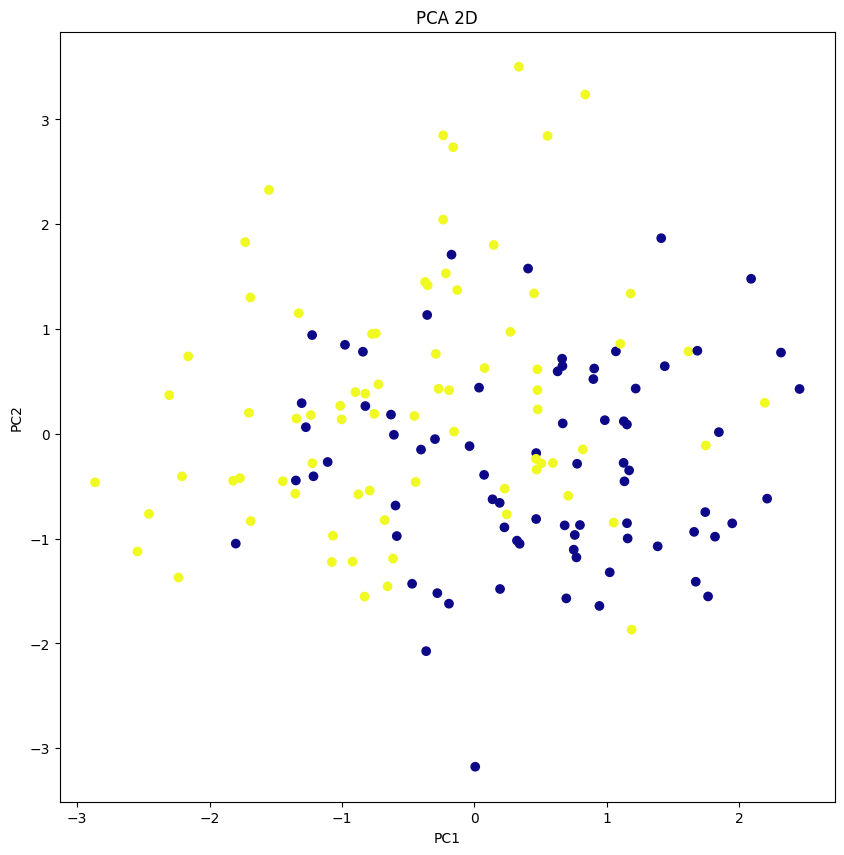

In [8]:
principal.components_

plt.figure(figsize=(10,10))

plt.title('PCA 2D')

plt.scatter(
    x[:,0],
    x[:,1],
    c=data['Sold'],
    cmap='plasma'
)

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()

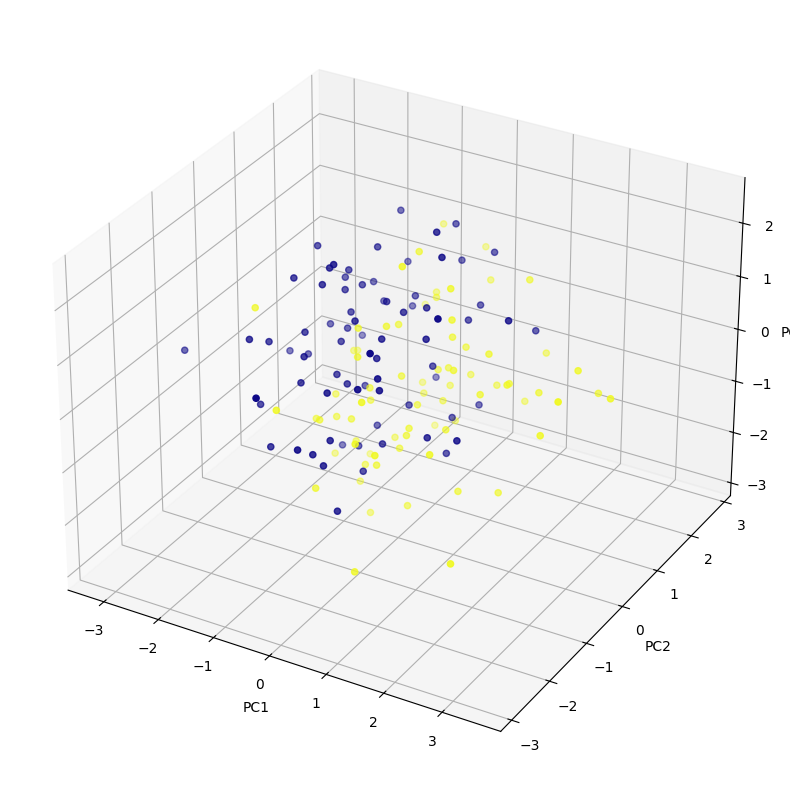

In [9]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,10))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    x[:,1],
    x[:,2],
    x[:,0],
    c=data['Sold'],
    cmap='plasma'
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.show()

In [10]:
print(principal.explained_variance_ratio_)

[0.13116519 0.12145932 0.117987  ]
